# Naive Bayes Text Classification

### Based on the Simplilearn tutorial, "Naive Bayes Classifier | Naive Bayes Algorithm | Naive Bayes Classifier With Example | Simplilearn"

Link to tutorial on Youtube: https://www.youtube.com/watch?v=l3dZ6ZNFjo0

In [1]:
# Loading the necessary libraries
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()

from sklearn.datasets import fetch_20newsgroups

In [2]:
# Get data
data = fetch_20newsgroups()
data.target_names

['alt.atheism',
 'comp.graphics',
 'comp.os.ms-windows.misc',
 'comp.sys.ibm.pc.hardware',
 'comp.sys.mac.hardware',
 'comp.windows.x',
 'misc.forsale',
 'rec.autos',
 'rec.motorcycles',
 'rec.sport.baseball',
 'rec.sport.hockey',
 'sci.crypt',
 'sci.electronics',
 'sci.med',
 'sci.space',
 'soc.religion.christian',
 'talk.politics.guns',
 'talk.politics.mideast',
 'talk.politics.misc',
 'talk.religion.misc']

In [6]:
categories = ['alt.atheism', 'comp.graphics', 'comp.os.ms-windows.misc',
              'comp.sys.mac.hardware','comp.windows.x','misc.forsale',
              'rec.autos','rec.motorcycles','rec.sport.baseball',
              'rec.sport.hockey','sci.crypt','sci.electronics','sci.med',
              'sci.space','soc.religion.christian','talk.politics.guns',
              'talk.politics.mideast','talk.politics.misc','talk.religion.misc']

# Training the data on these categories
train = fetch_20newsgroups(subset='train', categories=categories)
# Testing the data for these categories
test = fetch_20newsgroups(subset='test', categories=categories)

print(train.data[5])

From: jerry.ciz@rose.com (jerry ciz)
Subject: SYNOPTICS LAN H/W
Article-I.D.: rose.1993Apr17.070759.18605
Distribution: misc
Organization: Rose Media Inc, Toronto, Ontario.
Lines: 21
X-Gated-By: Usenet <==> RoseMail Gateway (v1.70)


                                             
                    
                    For Sale or Trade
         2 SYNOPTICS Model 2510, LAN concentrators

o new, never used, original packing
o each unit has 12 RJ45 ports for 10 Mbps ethernet connectivity
o included are one power supply, manuals, bracket hardware for 19" racks
o you can setup LANs using unshielded twisted pair (UTP) telephone wiring

o both units $400
o or, trade.... I'm looking for 386DX/486DX PC hardware


email:  jerry.ciz@rose.com
phone:  416-855-6205 (24hrs, 7days a week)

---
   RoseReader 2.10  R003050 Entered at [ROSE]
   RoseMail 2.10 : RoseNet<=>Usenet Gateway : Rose Media 416-733-2285



In [9]:
# Importing necessary packages
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline

# Creating a model based on Multinomial Naive Bayes
model = make_pipeline(TfidfVectorizer(), MultinomialNB())

# Training the model with the train data
model.fit(train.data, train.target)

# Creating labels for the test data
labels = model.predict(test.data)

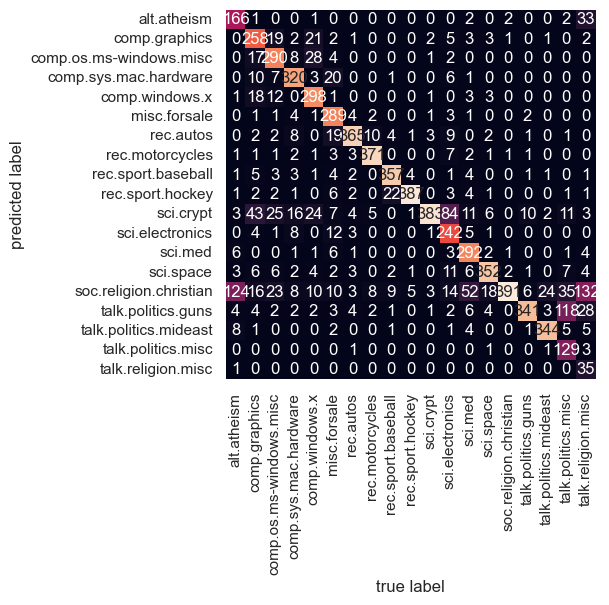

In [10]:
# Creating confusion matrix and heat map
from sklearn.metrics import confusion_matrix
mat = confusion_matrix(test.target, labels)
sns.heatmap(mat.T, square=True, annot=True, fmt='d',
           cbar=False, xticklabels=train.target_names,
           yticklabels=train.target_names)

# Plotting Heatmap of Confusion Matrix
plt.xlabel('true label')
plt.ylabel('predicted label');

In [11]:
# Predicting category on new data based on trained model
def predict_category(s, train=train, model=model):
    pred = model.predict([s])
    return train.target_names[pred[0]]

In [12]:
predict_category('Jesus Christ')

'soc.religion.christian'

In [13]:
predict_category('Sending load to International Space Station')

'sci.space'

In [14]:
predict_category('BMW is better than Audi')

'rec.autos'

In [17]:
predict_category('Prime minister of the United Kingdom')

'talk.politics.mideast'

In [ ]:
### END ###